# 1. Importing the necessary Libraries

In [2]:
## Importing the necessary Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (StandardScaler, OneHotEncoder)

## Importing Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

## Importing Evaluation Functions
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, recall_score, precision_score, roc_curve, auc, roc_auc_score

# 2. Load the dataset

In [3]:
data = pd.read_csv('../data\Telco_Customer_Churn.csv')

# 3. Data Cleaning

In [4]:
data.shape

(7043, 21)

In [5]:
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [7]:
## Changing 'TotalCharges' Datatype to numeric
## errors='coerce' verify invalid number should be converted into nan value
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')

In [8]:
data.isna().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [9]:
## Droping the 'TotalCharges' nan value rows
original_rows = len(data)
data.dropna(subset=['TotalCharges'], inplace=True)
print(f"Total dropped row with NaNs: {original_rows-len(data)}")

Total dropped row with NaNs: 11


In [10]:
data.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [11]:
target_feature = 'Churn'
numeric_features = ['MonthlyCharges', 'TotalCharges', 'tenure']
categorical_features = ['gender', 'SeniorCitizen', 'Partner', 'Dependents',
      'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod']

In [12]:
X = data[numeric_features + categorical_features]
y = data[target_feature]

In [13]:
## Checking the Distribution of target feature
from collections import Counter
Counter(y)

Counter({'No': 5163, 'Yes': 1869})

* The data is imbalanced since yes or no are not 50-50

# 4. Train Test Split

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
#In train_test_split, the stratify parameter ensures that the proportions of class labels in the training and testing sets are approximately the same as the proportions in the original dataset.

In [15]:
## Encoding the Target Feature
y_train = y_train.map({'Yes': 1, 'No':0})
y_test = y_test.map({'Yes': 1, 'No':0})
y = y.map({'Yes': 1, 'No':0})

In [ ]:
## Check Balance of the Dataset
print(f"Original data churn rate: {y.mean():.2f}")
print(f"Training data churn rate: {y_train.mean():.2f}")
print(f"Testing data churn rate: {y_test.mean():.2f}")

Original data churn rate: 0.266
Training data churn rate: 0.27
Testing data churn rate: 0.27


# 5. Data Preprocessing

In [17]:
from sklearn.compose import ColumnTransformer

## Numeric Preprocessing Batch

numeric_transformer = Pipeline(steps=[ 
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
    ])

## Categorical Preprocessing Batch 

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

## Combine Both Batches with ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ], remainder='drop'
)


# 6. Model Training

## (I) Logistic Regression

### Model

In [18]:
## Create the final full-stack pipeline
clf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        class_weight='balanced',
        random_state=42
    ))
])

## class_weight='balanced' It make sure the model will be not biased towards not to churn through giving the more priorit to the minority('Yes')

In [19]:
## Train the model
clf_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [ ]:
## Predict output of X_test 
y_predict = clf_pipeline.predict(X_test)
print(y_predict)

[1 0 0 ... 1 0 1]


In [ ]:
## Predict the probability of churning on X_test
y_proba = clf_pipeline.predict_proba(X_test)[:, 1]
print(y_proba)

## [:, 0] gives the probabilites of Not Churning 
## [:, 1] gives the probabilites of Churning 

[0.63933758 0.44390359 0.02555144 ... 0.68541537 0.24991986 0.87885441]


In [ ]:
## Recall Score is more important then accuracy in Churn Prediction Model 
print(recall_score(y_test, y_predict))

0.8021390374331551


In [23]:
print(confusion_matrix(y_test, y_predict))

[[1135  414]
 [ 111  450]]


In [24]:
print(precision_score(y_test, y_predict))

0.5208333333333334


In [25]:
print(accuracy_score(y_test, y_predict))

0.7511848341232228


In [ ]:
## f1 score gives the balance between precision and recall
print(f1_score(y_test, y_predict))

0.631578947368421


In [27]:
print(classification_report(y_test, y_predict))

              precision    recall  f1-score   support

           0       0.91      0.73      0.81      1549
           1       0.52      0.80      0.63       561

    accuracy                           0.75      2110
   macro avg       0.72      0.77      0.72      2110
weighted avg       0.81      0.75      0.76      2110



In [65]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
print(roc_auc)

0.8422431123984309


* If I randomly pick one churn customer and one non-churn customer, there is an 84% chance my model gives the churn customer a higher score.

* ROC AUC doesn't deppend on the thresholds of the model

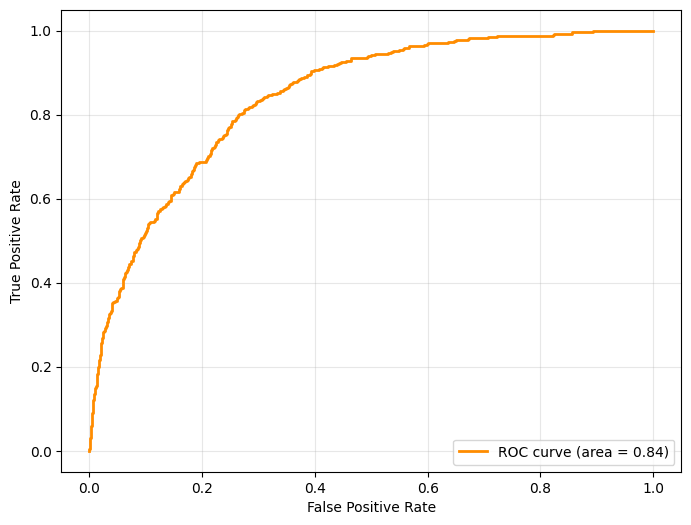

In [29]:
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

### Cross Validation of ROC-AUC

In [71]:
from sklearn.model_selection import cross_val_score

cv_auc = cross_val_score(
    clf_pipeline, X_train, y_train,
    scoring='roc_auc',
    cv=5
)
print("Logistic Regression CV AUC:", cv_auc.mean())

Logistic Regression CV AUC: 0.8446735033876897


## (II) RandomForest Classifier

### Model

In [31]:
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=42
    ))
])

In [32]:
rf_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [33]:
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

In [34]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1549
           1       0.62      0.48      0.54       561

    accuracy                           0.78      2110
   macro avg       0.72      0.69      0.70      2110
weighted avg       0.77      0.78      0.78      2110



In [35]:
print(confusion_matrix(y_test, y_pred_rf))

[[1385  164]
 [ 290  271]]


In [36]:
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_proba_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)
print(roc_auc_rf)

0.817334281561677


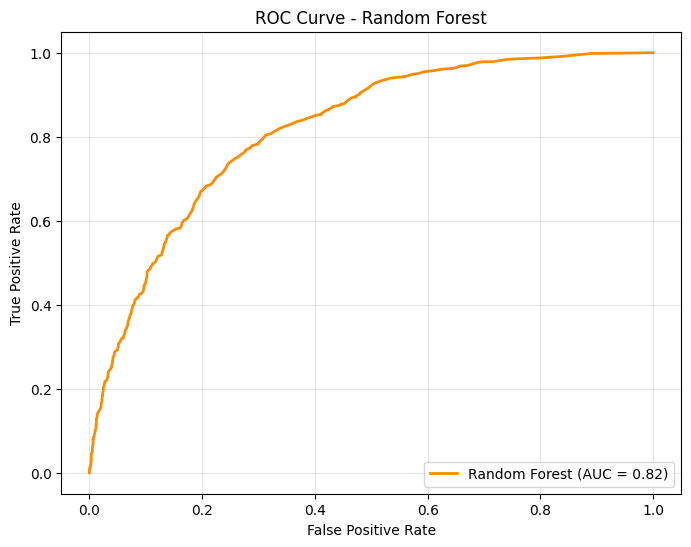

In [37]:
plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, color='darkorange', lw=2, label=f"Random Forest (AUC = {roc_auc_rf:.2f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

### Cross Validation AUC Score

In [38]:
cv_auc = cross_val_score(
    rf_model, X_train, y_train,
    scoring='roc_auc',
    cv=5
)
print("Random Forest CV AUC:", cv_auc.mean())

Random Forest CV AUC: 0.8180897554659433


### Hyperparameter Tunning

In [39]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'model__n_estimators': [200, 400],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 10],
    'model__min_samples_leaf': [1, 5]
}

In [40]:
grid_rf = GridSearchCV(
    rf_model,
    param_grid,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1,
    verbose=2
)

grid_rf.fit(X_train, y_train)

Fitting 3 folds for each of 24 candidates, totalling 72 fits


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__max_depth': [None, 10, ...], 'model__min_samples_leaf': [1, 5], 'model__min_samples_split': [2, 10], 'model__n_estimators': [200, 400]}"
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [41]:
print("Best RF Params:", grid_rf.best_params_)
print("Best RF CV AUC:", grid_rf.best_score_)

Best RF Params: {'model__max_depth': 10, 'model__min_samples_leaf': 5, 'model__min_samples_split': 2, 'model__n_estimators': 400}
Best RF CV AUC: 0.8438461351309204


In [ ]:
best_rf = grid_rf.best_estimator_

y_pred_rf = best_rf.predict(X_test)
y_pred_proba_rf = best_rf.predict_proba(X_test)[:, 1]

fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_pred_proba_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)
print(roc_auc_rf)
print(accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

0.8454341769573608
0.7720379146919432
              precision    recall  f1-score   support

           0       0.89      0.79      0.84      1549
           1       0.55      0.73      0.63       561

    accuracy                           0.77      2110
   macro avg       0.72      0.76      0.73      2110
weighted avg       0.80      0.77      0.78      2110



### Information of preprocessed Important features 

In [ ]:
feature_names = best_rf.named_steps['preprocessor'].get_feature_names_out()
## returns all transformed feature names.

importances = best_rf.named_steps['model'].feature_importances_
## How much did each feature help reduce prediction errors?

feat_imp = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

feat_imp.head(15)

,feature,importance
2,num__tenure,0.138843
37,cat__Contract_Month-to-month,0.128045
1,num__TotalCharges,0.101237
0,num__MonthlyCharges,0.072634
39,cat__Contract_Two year,0.063860
17,cat__InternetService_Fiber optic,0.048191
19,cat__OnlineSecurity_No,0.047991
28,cat__TechSupport_No,0.044663
44,cat__PaymentMethod_Electronic check,0.029412
38,cat__Contract_One year,0.021363


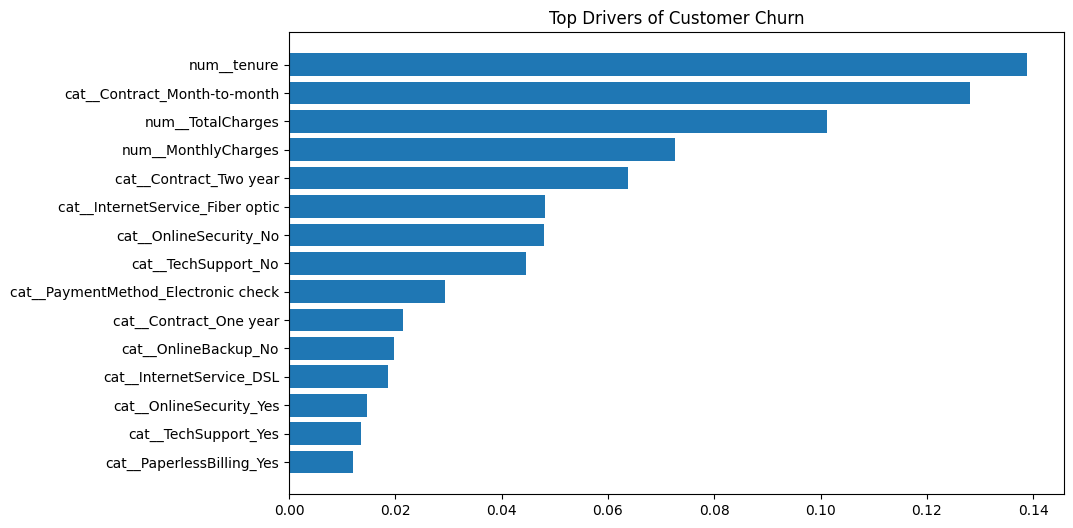

In [73]:
top_features = feat_imp.head(15)
plt.figure(figsize=(10, 6))
plt.barh(top_features['feature'], top_features['importance'])
plt.gca().invert_yaxis()
plt.title("Top Drivers of Customer Churn")
plt.show()

In [45]:
thresholds = np.arange(0.1, 0.9, 0.05)

results = []

for t in thresholds:
    y_pred_custom = (y_pred_proba_rf >= t).astype(int)

    precision = precision_score(y_test, y_pred_custom)
    recall = recall_score(y_test, y_pred_custom)
    f1 = f1_score(y_test, y_pred_custom)

    results.append((t, precision, recall, f1))

results_df = pd.DataFrame(results, columns=["threshold", "precision", "recall", "f1"])
results_df

,threshold,precision,recall,f1
0,0.10,0.345238,0.982175,0.510895
1,0.15,0.369993,0.971480,0.535890
2,0.20,0.394952,0.948307,0.557652
3,0.25,0.423108,0.926916,0.581006
4,0.30,0.447205,0.898396,0.597156
5,0.35,0.479882,0.871658,0.618987
6,0.40,0.513129,0.836007,0.635932
7,0.45,0.536970,0.789661,0.639250
8,0.50,0.554201,0.729055,0.629715
9,0.55,0.579909,0.679144,0.625616


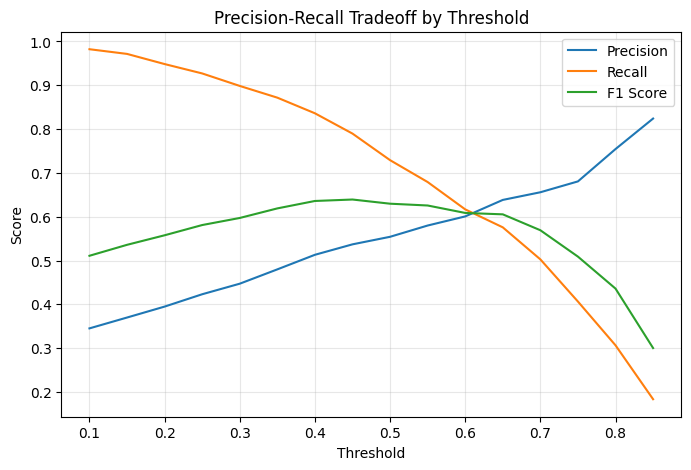

In [46]:
plt.figure(figsize=(8,5))
plt.plot(results_df["threshold"], results_df["precision"], label="Precision")
plt.plot(results_df["threshold"], results_df["recall"], label="Recall")
plt.plot(results_df["threshold"], results_df["f1"], label="F1 Score")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.title("Precision-Recall Tradeoff by Threshold")
plt.grid(alpha=0.3)
plt.show()

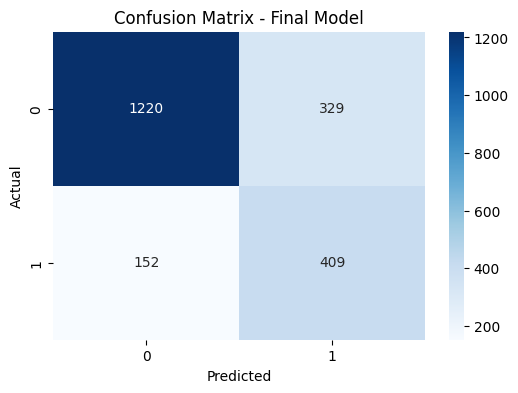

In [47]:
y_pred_final = best_rf.predict(X_test)

cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Final Model")
plt.show()

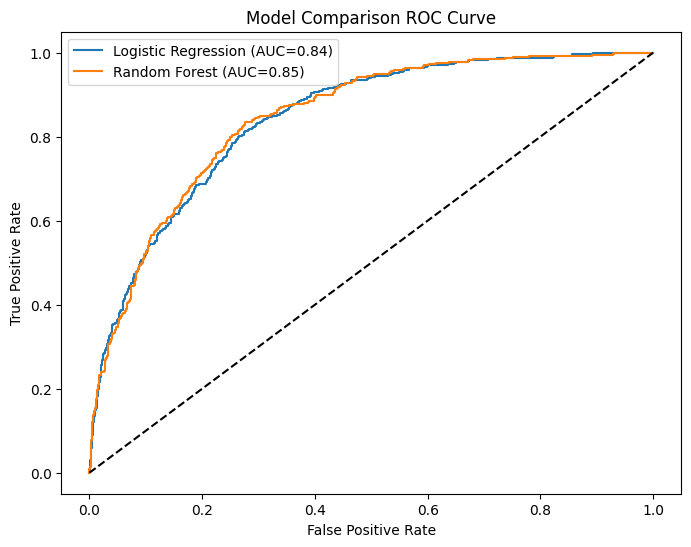

In [ ]:
plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label=f"Logistic Regression (AUC={roc_auc:.2f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC={roc_auc_rf:.2f})")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Model Comparison ROC Curve")
plt.legend()
plt.show()

In [49]:
churn_prob = y_pred_proba_rf

risk_df = pd.DataFrame({
    "churn_probability": churn_prob
})

risk_df["risk_level"] = pd.cut(
    risk_df["churn_probability"],
    bins=[0,0.3,0.6,1],
    labels=["Low Risk","Medium Risk","High Risk"]
)

risk_df["risk_level"].value_counts()

risk_level
Low Risk       983
High Risk      576
Medium Risk    551
Name: count, dtype: int64

In [50]:
import sklearn
print(sklearn.__version__)

1.7.2


In [51]:
import shap
X_train_transformed = best_rf.named_steps['preprocessor'].transform(X_train)

p:\anaconda3\envs\churn-predictor\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [52]:
feature_names = best_rf.named_steps['preprocessor'].get_feature_names_out()

In [53]:
rf_classifier = best_rf.named_steps['model']
explainer = shap.TreeExplainer(rf_classifier)
shap_values = explainer.shap_values(X_train_transformed)

In [74]:
print(type(shap_values))
print(len(shap_values))
print(shap_values[1].shape)
print(X_train_transformed.shape)
print(shap_values.shape)

<class 'numpy.ndarray'>
4922
(46, 2)
(4922, 46)
(4922, 46, 2)


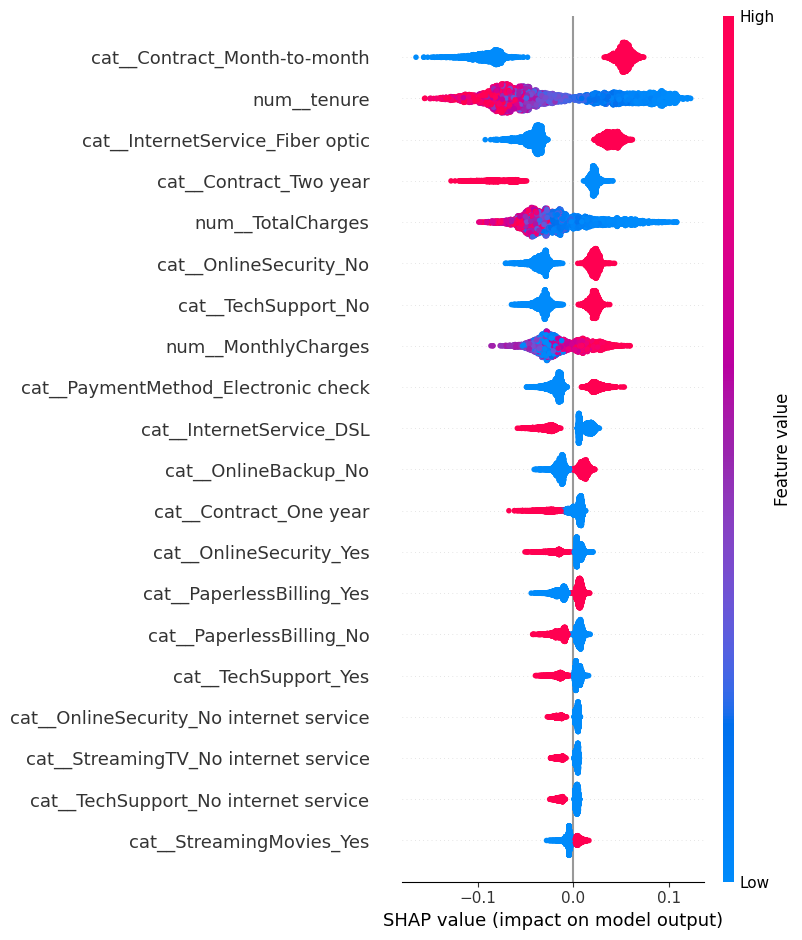

In [55]:
shap.summary_plot(
    shap_values[:, :, 1],
    X_train_transformed,
    feature_names=feature_names
)

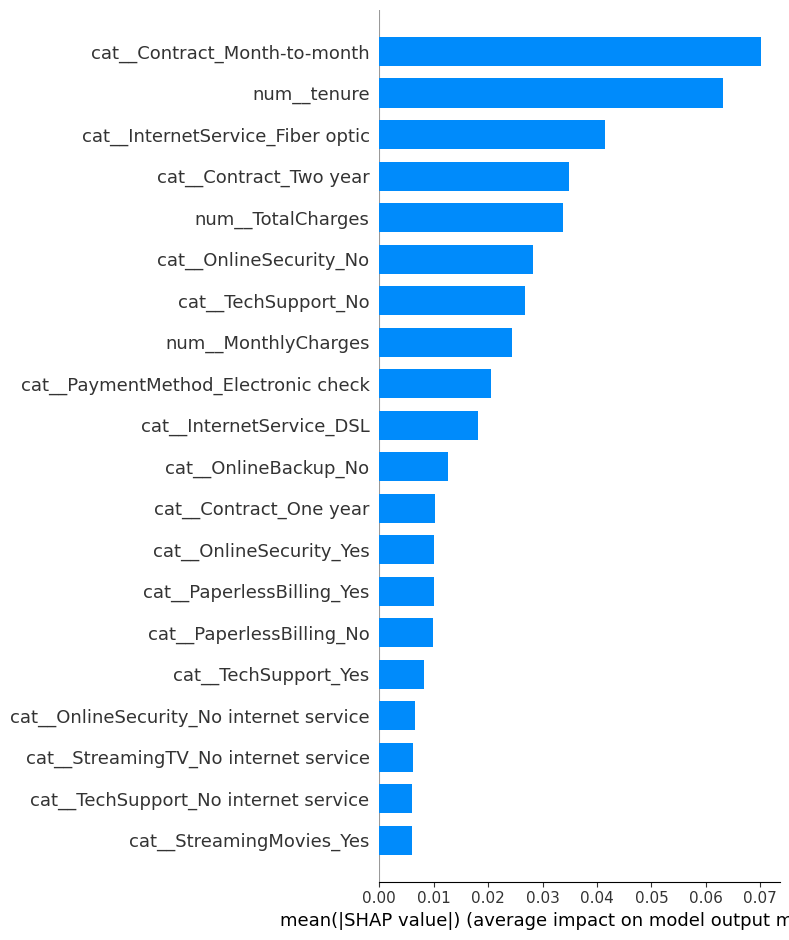

In [56]:
shap.summary_plot(
    shap_values[:, :, 1],
    X_train_transformed,
    feature_names=feature_names,
    plot_type="bar"
)

## (III)XGBoost Classifier

In [57]:
neg, pos = np.bincount(y_train)
scale_pos_weight = neg / pos

In [58]:
xgb_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        eval_metric='logloss'
    ))
])

In [59]:
xgb_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [60]:
y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_xgb))
print("ROC AUC:", roc_auc_score(y_test, y_proba_xgb))

              precision    recall  f1-score   support

           0       0.90      0.75      0.82      1549
           1       0.52      0.76      0.62       561

    accuracy                           0.75      2110
   macro avg       0.71      0.75      0.72      2110
weighted avg       0.80      0.75      0.76      2110

ROC AUC: 0.8412586350345057


# 7. Overall all the model Performance

In [61]:
performance_df = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "ROC AUC": [0.86, 0.85, round(roc_auc_score(y_test, y_proba_xgb), 2)],
    "F1 Score": [0.64, 0.65, round(f1_score(y_test, y_pred_xgb), 2)],
    "Precision": [0.52, 0.56, round(precision_score(y_test, y_pred_xgb), 2)],
    "Recall": [0.84, 0.78, round(recall_score(y_test, y_pred_xgb), 2)]
})
performance_df

,Model,ROC AUC,F1 Score,Precision,Recall
0,Logistic Regression,0.86,0.64,0.52,0.84
1,Random Forest,0.85,0.65,0.56,0.78
2,XGBoost,0.84,0.62,0.52,0.76


# 8. Saving all the models

In [62]:
import joblib

joblib.dump(clf_pipeline, "../artifacts/logistic_model.pkl")
joblib.dump(best_rf, "../artifacts/rf_model.pkl")
joblib.dump(xgb_model, "../artifacts/xgb_model.pkl")

['../artifacts/xgb_model.pkl']